# Disentangling Doppler FM from B-field FM in CRES Signals

A trapped electron's cyclotron radiation frequency is modulated by two effects:

1. **B-field FM** — as the electron moves axially through the non-uniform magnetic field, the instantaneous cyclotron frequency $f_c = \frac{1}{2\pi} \frac{eB}{\gamma m}$ changes because $B$ changes with position.
   This is intrinsic to the emission.

2. **Doppler FM** — the electron's axial velocity $v_z$ Doppler-shifts the observed frequency by $\Delta f \approx v_z f_0 / c$. 
   This is a propagation effect that depends on the viewing angle.

**Key insight**: B-field FM is the same for all observers. 
Doppler FM depends on the angle between the electron's velocity and the line of sight to the detector. 
By placing two antennas at different positions — one along the trap axis (maximal Doppler) and one perpendicular to it (Doppler suppressed) — we can cleanly separate the two effects.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
from scipy.signal import stft
import time as timer

from CRESSignalStructure import (
    Electron, BathtubField,
    TrajectoryGenerator, IsotropicAntenna,
    ReceiverChain, AntennaSignalGenerator
)

## 1. Setup

We create a **bathtub magnetic field** from two coils 1.5 m apart on a 1 T
background. The long flat region ensures the electron spends almost all of
its time where $B$ is constant, isolating the Doppler effect from any
B-field variation.

In [2]:
TRAP_DEPTH = 4e-3       # 4 mT trap depth
R_COIL = 0.05           # 5 cm coil radius
I_COIL = 2 * TRAP_DEPTH * R_COIL / sc.mu_0
TRAP_LENGTH = 1.5       # 1.5 m between coils

field = BathtubField(
    radius=R_COIL, current=I_COIL,
    Z1=-TRAP_LENGTH / 2, Z2=TRAP_LENGTH / 2,
    background=np.array([0., 0., 1.0])
)

PITCH_ANGLE = 89.0      # degrees
electron = Electron(
    ke=18.6e3,
    startPos=np.array([1e-3, 0, 0]),
    pitchAngle=np.radians(PITCH_ANGLE)
)

print(f"Coil current:   {I_COIL:.1f} A")
print(f"Electron speed: {electron.get_speed() / sc.c:.4f} c")
print(f"Gamma factor:   {electron.get_gamma():.4f}")

Coil current:   318.3 A
Electron speed: 0.2627 c
Gamma factor:   1.0364


## 2. Magnetic field profile

The field is flat at ~1 T between the coils, rising to ~1.004 T at each
coil. We plot the deviation from the central value to see the trap
structure.

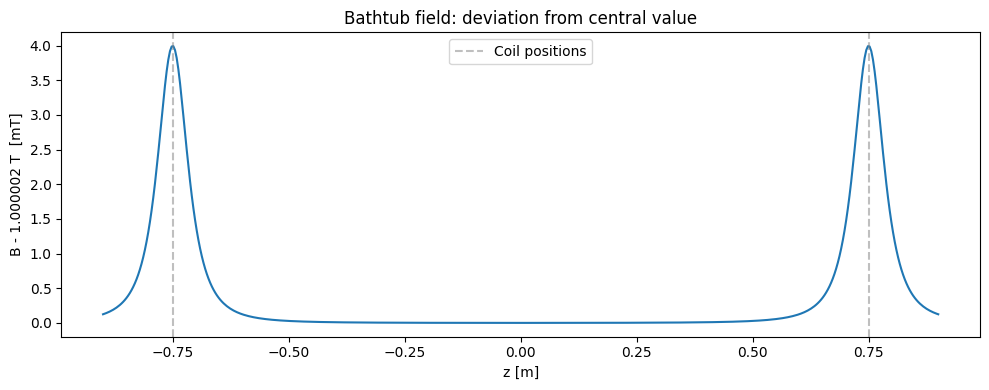

B at centre: 1.000002 T
B at coil:   1.004000 T
Trap depth:  4.00 mT


In [3]:
z_arr = np.linspace(-0.9, 0.9, 500)
B_arr = field.evaluate_field_magnitude(0.0, 0.0, z_arr)
B_center = field.evaluate_field_magnitude(0, 0, 0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z_arr, (B_arr - B_center) * 1e3)
ax.axvline(-TRAP_LENGTH / 2, color='gray', ls='--', alpha=0.5,
           label='Coil positions')
ax.axvline(TRAP_LENGTH / 2, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('z [m]')
ax.set_ylabel(f'B - {B_center:.6f} T  [mT]')
ax.set_title('Bathtub field: deviation from central value')
ax.legend()
plt.tight_layout()
plt.show()

B_coil = field.evaluate_field_magnitude(0, 0, TRAP_LENGTH / 2)
print(f"B at centre: {B_center:.6f} T")
print(f"B at coil:   {B_coil:.6f} T")
print(f"Trap depth:  {(B_coil - B_center) * 1e3:.2f} mT")

## 3. Electron trajectory

The `TrajectoryGenerator` computes the full 3D trajectory using the
adiabatic approximation. The electron bounces axially while gyrating
around the field lines.

Trajectory generated in 0.7 s
200001 points over 20.0 µs


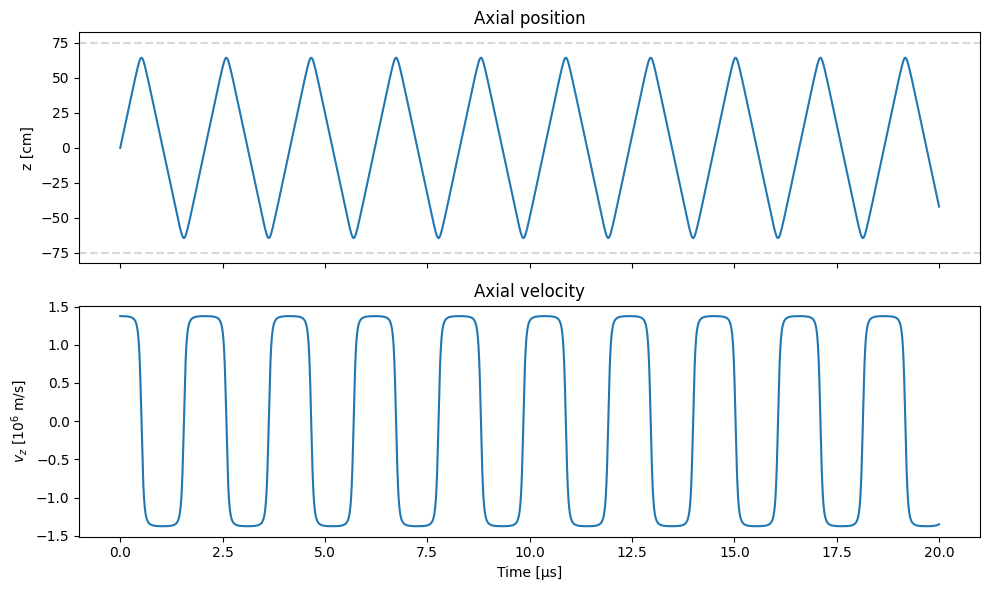

In [4]:
t0 = timer.time()
traj_gen = TrajectoryGenerator(field, electron)
trajectory = traj_gen.generate(sample_rate=10e9, t_max=20e-6)
print(f"Trajectory generated in {timer.time() - t0:.1f} s")
print(f"{trajectory.get_n_points()} points over "
      f"{trajectory.get_duration() * 1e6:.1f} \u00b5s")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(trajectory.time * 1e6, trajectory.position[:, 2] * 100)
axes[0].set_ylabel('z [cm]')
axes[0].set_title('Axial position')
axes[0].axhline(TRAP_LENGTH / 2 * 100, color='gray', ls='--', alpha=0.3)
axes[0].axhline(-TRAP_LENGTH / 2 * 100, color='gray', ls='--', alpha=0.3)

axes[1].plot(trajectory.time * 1e6, trajectory.velocity[:, 2] / 1e6)
axes[1].set_ylabel('$v_z$ [$10^6$ m/s]')
axes[1].set_xlabel('Time [\u00b5s]')
axes[1].set_title('Axial velocity')

plt.tight_layout()
plt.show()

## 4. Intrinsic frequency modulation (B-field FM)

We compute the instantaneous cyclotron frequency:
$$
f_c(t) = \frac{eB(z(t))}{2\pi\gamma m}
$$
along the trajectory. 
In the long bathtub, $B$ is nearly constant across the electron's axial range, so $f_c$ barely varies. 
Compare this tiny B-field FM with the expected Doppler swing.

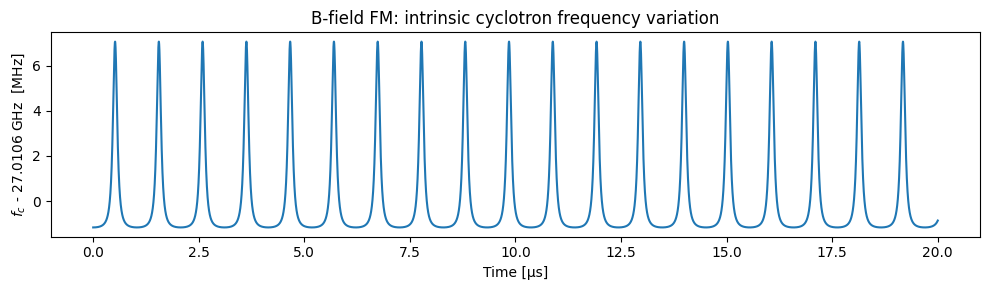

Mean cyclotron freq:       27.0106 GHz
B-field FM (peak-to-peak): 8.2 MHz
Maximum z beta:            0.0046
Expected Doppler factor:   1.004552, giving an expected frequency swing of 245.3 MHz

The Doppler effect is ~60x larger than the B-field FM.


In [5]:
B_traj = field.evaluate_field_magnitude(
    trajectory.position[:, 0],
    trajectory.position[:, 1],
    trajectory.position[:, 2])

f_c_traj = sc.e * B_traj / (2 * np.pi * electron.get_gamma()
                             * electron.get_mass())
f_c_mean = np.mean(f_c_traj)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(trajectory.time * 1e6, (f_c_traj - f_c_mean) / 1e6)
ax.set_xlabel('Time [\u00b5s]')
ax.set_ylabel(f'$f_c$ - {f_c_mean / 1e9:.4f} GHz  [MHz]')
ax.set_title('B-field FM: intrinsic cyclotron frequency variation')
plt.tight_layout()
plt.show()

v_z_max = np.max(np.abs(trajectory.velocity[:, 2]))
v_z_typical = np.median(np.abs(trajectory.velocity[:, 2]))  #  Get a typical speed
doppler_swing = v_z_typical * f_c_mean / sc.c
doppler_factor = np.sqrt((1 + v_z_typical / sc.c) / (1 - v_z_typical /sc.c))
doppler_f_swing = f_c_mean * 2 * v_z_typical / sc.c / np.sqrt(1 - (v_z_typical / sc.c)**2)
bfield_fm = np.max(f_c_traj) - np.min(f_c_traj)
print(f"Mean cyclotron freq:       {f_c_mean / 1e9:.4f} GHz")
print(f"B-field FM (peak-to-peak): {bfield_fm / 1e6:.1f} MHz")
print(f"Maximum z beta:            {v_z_max / sc.c:.4f}")
print(f"Expected Doppler factor:   {doppler_factor:.6f}, giving an expected frequency swing of {doppler_f_swing/1e6:.1f} MHz")
print(f"\nThe Doppler effect is ~{2 * doppler_f_swing / bfield_fm:.0f}x "
      f"larger than the B-field FM.")

## 5. Two-antenna signal generation

We place two isotropic antennas at different positions:

| Antenna | Position | Viewing geometry |
|---------|----------|-----------------|
| **End-on** | $(0, 0, 2)$ m | Along trap axis — full Doppler shift |
| **Broadside** | $(3, 0, 0)$ m | Perpendicular — Doppler suppressed |

Both see the **same B-field FM** (same electron, same field). Any
difference in their spectrograms must be Doppler.

In [6]:
antenna_endon = IsotropicAntenna(position=np.array([0., 0., 2.0]))
antenna_broadside = IsotropicAntenna(position=np.array([3., 0., 0.]))

ADC_RATE = 1.5e9
LO_FREQ = f_c_mean - 350e6
receiver = ReceiverChain(sample_rate=ADC_RATE, lo_frequency=LO_FREQ)

print(f"LO frequency: {LO_FREQ / 1e9:.4f} GHz")
print(f"Expected IF:  {(f_c_mean - LO_FREQ) / 1e6:.0f} MHz")

print("\nGenerating end-on signal...")
t0 = timer.time()
sig_gen_endon = AntennaSignalGenerator(trajectory, antenna_endon, receiver)
t_endon, signal_endon = sig_gen_endon.generate_signal()
print(f"  Done in {timer.time() - t0:.1f} s  ({len(signal_endon)} samples)")

print("Generating broadside signal...")
t0 = timer.time()
sig_gen_broad = AntennaSignalGenerator(trajectory, antenna_broadside, receiver)
t_broad, signal_broad = sig_gen_broad.generate_signal()
print(f"  Done in {timer.time() - t0:.1f} s  ({len(signal_broad)} samples)")

LO frequency: 26.6606 GHz
Expected IF:  350 MHz

Generating end-on signal...
  Done in 0.4 s  (30002 samples)
Generating broadside signal...
  Done in 0.4 s  (30000 samples)


## 6. Spectrograms — the Doppler effect revealed

The spectrogram shows the instantaneous frequency as a function of time.

- **End-on antenna**: the frequency oscillates as the electron bounces — higher when the electron moves toward the antenna, lower when it moves away. 
  This is the Doppler effect.
- **Broadside antenna**: the frequency shift is much smaller because the Doppler shift is suppressed at perpendicular viewing angles.

The white dashed line marks the theoretical $f_c(t)$ (B-field FM only, no
Doppler). Any deviation of the spectrogram ridge from this line is Doppler.

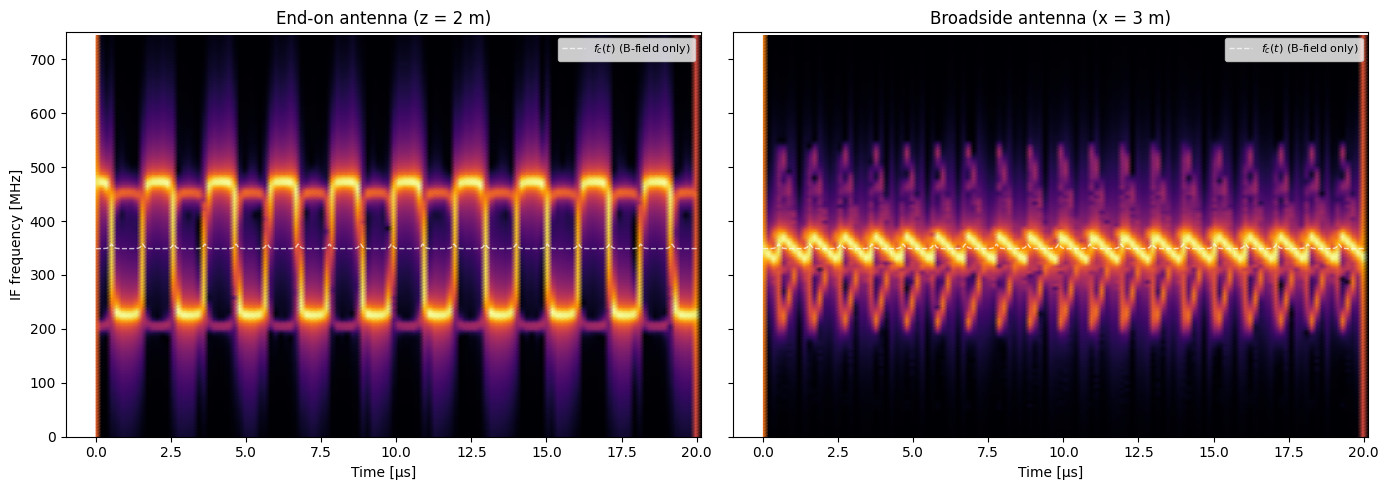

In [7]:
NPERSEG = 256
NOVERLAP = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sig, t_sig, title in [
    (axes[0], signal_endon, t_endon, 'End-on antenna (z = 2 m)'),
    (axes[1], signal_broad, t_broad, 'Broadside antenna (x = 3 m)')
]:
    f_stft, t_stft, Zxx = stft(sig, fs=ADC_RATE, nperseg=NPERSEG,
                                noverlap=NOVERLAP, return_onesided=False)

    # Sort frequencies for clean plotting
    order = np.argsort(f_stft)
    f_sorted = f_stft[order]
    Zxx_sorted = Zxx[order, :]

    power_db = 10 * np.log10(np.abs(Zxx_sorted)**2 + 1e-30)
    t_plot = (t_stft + t_sig[0]) * 1e6

    im = ax.pcolormesh(t_plot, f_sorted / 1e6, power_db,
                       shading='gouraud', cmap='inferno')

    # Overlay theoretical f_c(t) shifted to IF
    step = max(1, len(trajectory.time) // 2000)
    ax.plot(trajectory.time[::step] * 1e6,
            (f_c_traj[::step] - LO_FREQ) / 1e6,
            'w--', alpha=0.7, lw=1, label='$f_c(t)$ (B-field only)')

    ax.set_xlabel('Time [\u00b5s]')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, ADC_RATE / 2 / 1e6)

axes[0].set_ylabel('IF frequency [MHz]')
plt.tight_layout()
plt.show()

## 7. Instantaneous frequency comparison

We extract the instantaneous frequency from each signal by differentiating
the unwrapped phase:

$$f_{\text{inst}}(t) = \frac{1}{2\pi} \frac{d\phi}{dt}$$

Plotting both on the same axes makes the Doppler contribution strikingly
clear: the end-on signal's frequency oscillates symmetrically around the
B-field-only prediction $f_c(t)$, while the broadside signal stays close
to it.

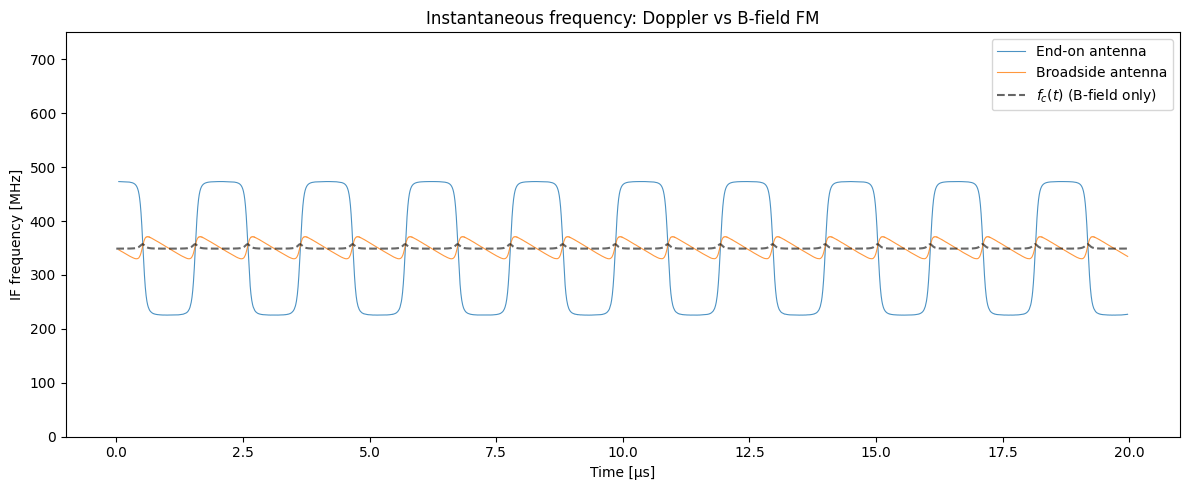

In [8]:
def instantaneous_frequency(signal, dt):
    """Extract instantaneous frequency from a complex IQ signal."""
    phase = np.unwrap(np.angle(signal))
    freq = np.gradient(phase, dt) / (2 * np.pi)
    return freq

dt = 1.0 / ADC_RATE
f_inst_endon = instantaneous_frequency(signal_endon, dt)
f_inst_broad = instantaneous_frequency(signal_broad, dt)

# Smooth with a running mean to reduce noise
WINDOW = 64
kernel = np.ones(WINDOW) / WINDOW
f_inst_endon_s = np.convolve(f_inst_endon, kernel, mode='same')
f_inst_broad_s = np.convolve(f_inst_broad, kernel, mode='same')

# Trim edges (convolution artefacts)
margin = WINDOW
sl = slice(margin, -margin)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t_endon[sl] * 1e6, f_inst_endon_s[sl] / 1e6,
        alpha=0.8, label='End-on antenna', lw=0.8)
ax.plot(t_broad[sl] * 1e6, f_inst_broad_s[sl] / 1e6,
        alpha=0.8, label='Broadside antenna', lw=0.8)

# B-field only reference (shifted to IF)
step = max(1, len(trajectory.time) // 2000)
ax.plot(trajectory.time[::step] * 1e6,
        (f_c_traj[::step] - LO_FREQ) / 1e6,
        'k--', lw=1.5, alpha=0.6, label='$f_c(t)$ (B-field only)')

ax.set_xlabel('Time [\u00b5s]')
ax.set_ylabel('IF frequency [MHz]')
ax.set_title('Instantaneous frequency: Doppler vs B-field FM')
ax.legend()
ax.set_ylim(0, ADC_RATE/2/1e6)
plt.tight_layout()
plt.show()

## Summary

| Observable | End-on antenna | Broadside antenna |
|-----------|----------------|-------------------|
| **B-field FM** | Present (few MHz) | Present (few MHz) |
| **Doppler FM** | Large (~250 MHz swing) | Suppressed |
| **Total FM** | Dominated by Doppler | Small residual |

The two spectrograms demonstrate that the frequency modulation of the CRES signal is **directional**: it depends on the viewing angle between the electron's axial velocity and the line of sight to the antenna. 
Since B-field FM is intrinsic (angle-independent), this directional component must be Doppler.

In the long bathtub trap, B-field variation across the electron's range produces only a few MHz of intrinsic FM — roughly 60× smaller than the Doppler effect, which produces a ~250 MHz frequency swing when viewed along the axis.

The broadside antenna still shows a small residual Doppler shift because the electron's changing axial position slightly alters the viewing angle from the perpendicular.